# Cross-category — Thị phần (pie chart)

So sánh **thị phần** giữa 5 category trên `fact_listing_snapshot` (full data · 2025-11-09 → 2026-04-09).

| Biểu đồ | Công thức thị phần |
|---------|-------------------|
| **Chart 1** — Liên hệ | `Σ contacts_24h` theo category ÷ tổng |
| **Chart 2** — Listing-days | `Σ listing-days` theo category ÷ tổng |

Mỗi chart nằm **một cell riêng** (không ghép 2 pie trong một output).

In [14]:
%matplotlib inline
import os
os.environ["MPL_SHOW"] = "1"

import importlib
import matplotlib.pyplot as plt
import pandas as pd

import eda_listing_snapshot_temporal_deep as snap
importlib.reload(snap)

snap.configure_matplotlib(notebook=True)
snap.check_data_dirs()
con = snap.connect_duckdb()
snap.ensure_caches(con)
snap.register_snap_view(con)

In [15]:
def load_ranking_with_shares(con) -> pd.DataFrame:
    ranking = snap.fetch_executive_frames(con)["ranking"].copy()
    ranking["total_contacts"] = ranking["avg_contacts_24h"] * ranking["listing_days"]
    ranking["share_contacts_pct"] = (
        100.0 * ranking["total_contacts"] / ranking["total_contacts"].sum()
    )
    ranking["share_listing_days_pct"] = (
        100.0 * ranking["listing_days"] / ranking["listing_days"].sum()
    )
    return ranking


def plot_market_share_pie(
    ranking: pd.DataFrame,
    *,
    share_col: str,
    title: str,
    legend_title: str,
    out_name: str,
    show: bool = True,
) -> None:
    """Một pie chart / một output — legend đặt dưới pie, tránh đè chữ."""
    n_days = int(ranking["listing_days"].sum())
    subtitle = snap.chart_subtitle(n_listing_days=n_days)
    footnote = (
        "Tỷ lệ liên hệ (%) = Σcontacts ÷ Σviews (theo category) · "
        "Thị phần pie = tỷ trọng tổng tích lũy"
    )

    r = ranking.sort_values(share_col, ascending=False)
    sizes = r[share_col].to_numpy()
    colors = [snap.PALETTE[int(c)] for c in r["category"]]
    rates = r["contact_rate_pct"].to_numpy()

    fig, ax = plt.subplots(figsize=(8, 6.5))
    fig.suptitle(title, fontweight="bold", fontsize=13, y=0.98)
    fig.text(0.5, 0.93, subtitle, ha="center", fontsize=9, color="#444444")
    fig.text(0.5, 0.04, footnote, ha="center", fontsize=9, style="italic", color="#555555")

    wedges, _, autotexts = ax.pie(
        sizes,
        colors=colors,
        autopct=lambda pct: f"{pct:.1f}%" if pct >= 3 else "",
        startangle=90,
        counterclock=False,
        pctdistance=0.72,
        wedgeprops={"linewidth": 0.8, "edgecolor": "white"},
    )
    for t in autotexts:
        t.set_fontsize(10)
        t.set_fontweight("bold")

    legend_lines = [
        f"{lbl}: {sz:.1f}% · tỷ lệ LH {rt:.2f}%"
        for lbl, sz, rt in zip(
            r["category_label"].str.split(" — ").str[-1],
            sizes,
            rates,
        )
    ]
    ax.legend(
        wedges,
        legend_lines,
        title=legend_title,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.06),
        ncol=1,
        fontsize=9,
        title_fontsize=10,
        frameon=False,
    )
    ax.set_aspect("equal")
    plt.subplots_adjust(top=0.86, bottom=0.22)

    out = snap.CROSS_DIR / out_name
    snap.CROSS_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(out, dpi=130, bbox_inches="tight")
    print("Saved", out)
    if show:
        plt.show()
    else:
        plt.close(fig)


CAT_ORDER_BAR = [1010, 1020, 1030, 1040, 1050]
# Palette dịu hơn snap.PALETTE gốc (cùng hue theo category)
PALETTE_BAR = {
    1010: "#52A675",
    1020: "#4F8FC9",
    1030: "#8E79B8",
    1040: "#D66B6B",
    1050: "#E09A55",
}


def plot_executive_contact_rate_bars(ranking: pd.DataFrame, show: bool = True) -> None:
    """Bar tỷ lệ liên hệ — thứ tự 1010→1050 (trên xuống), màu dịu."""
    r = ranking.copy()
    r["category"] = pd.Categorical(r["category"], categories=CAT_ORDER_BAR, ordered=True)
    r = r.sort_values("category")
    n_days = int(r["listing_days"].sum())
    subtitle = snap.chart_subtitle(n_listing_days=n_days)
    formula = "Công thức: Σcontacts ÷ Σviews (tính theo từng category)"

    fig, ax = plt.subplots(figsize=(10, 5.5))
    fig.patch.set_facecolor("#FAFAFA")
    ax.set_facecolor("#FAFAFA")
    fig.suptitle(
        "So sánh 5 category — Tỷ lệ liên hệ tổng thể",
        fontweight="bold",
        fontsize=13,
        y=0.97,
    )
    fig.text(
        0.5,
        0.885,
        subtitle,
        ha="center",
        va="top",
        fontsize=9,
        color="#555555",
    )
    fig.text(
        0.5,
        0.055,
        formula,
        ha="center",
        va="bottom",
        fontsize=8.5,
        style="italic",
        color="#666666",
    )

    y = r["category_label"].astype(str)
    colors = [PALETTE_BAR[int(c)] for c in r["category"]]
    bars = ax.barh(
        y,
        r["contact_rate_pct"],
        color=colors,
        edgecolor="white",
        linewidth=0.9,
        height=0.68,
        alpha=0.92,
    )
    xmax = r["contact_rate_pct"].max() * 1.12
    for bar, v in zip(bars, r["contact_rate_pct"]):
        ax.text(
            v + xmax * 0.02,
            bar.get_y() + bar.get_height() / 2,
            f"{v:.2f}%",
            va="center",
            ha="left",
            fontsize=9.5,
            fontweight="600",
            color="#333333",
        )
    ax.set_xlabel("Tỷ lệ liên hệ (%)", labelpad=10)
    ax.set_xlim(0, xmax)
    ax.invert_yaxis()  # 1010 trên cùng → 1050 dưới cùng
    ax.grid(axis="x", linestyle="--", alpha=0.35)
    ax.grid(axis="y", visible=False)
    plt.subplots_adjust(top=0.76, bottom=0.20, left=0.28, right=0.96)

    out = snap.CROSS_DIR / "fig_02_executive_contact_rate.png"
    snap.CROSS_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(out, dpi=130, bbox_inches="tight")
    print("Saved", out)
    if show:
        plt.show()
    else:
        plt.close(fig)

ranking = load_ranking_with_shares(con)
ranking[
    [
        "category_label",
        "share_contacts_pct",
        "share_listing_days_pct",
        "contact_rate_pct",
        "listing_days",
    ]
].sort_values("share_contacts_pct", ascending=False).round(2)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,category_label,share_contacts_pct,share_listing_days_pct,contact_rate_pct,listing_days
1,1020 — Nhà ở,51.45,48.40,10.01,9348383
3,1010 — Căn hộ / Chung cư,16.46,18.48,9.04,3568502
4,1050 — Phòng trọ,12.70,11.42,7.18,2206101
0,1040 — Đất,12.40,14.40,11.01,2781967
2,1030 — Văn phòng / Mặt bằng,6.99,7.30,9.56,1409227


## Bar chart — Tỷ lệ liên hệ tổng thể (sửa chú thích)

Bản thay cho chart bar trong `eda_listing_snapshot_temporal_deep.ipynb` / `step_cross`:
- **Trục X:** `Tỷ lệ liên hệ (%)` (ngắn, không ghi công thức trên trục)
- **Phạm vi dữ liệu:** dòng phụ dưới title
- **Công thức:** footnote dưới chart — không còn đè chữ như `ax.text(..., -0.12)` + xlabel dài

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_listing_snapshot/_cross/fig_02_executive_contact_rate.png


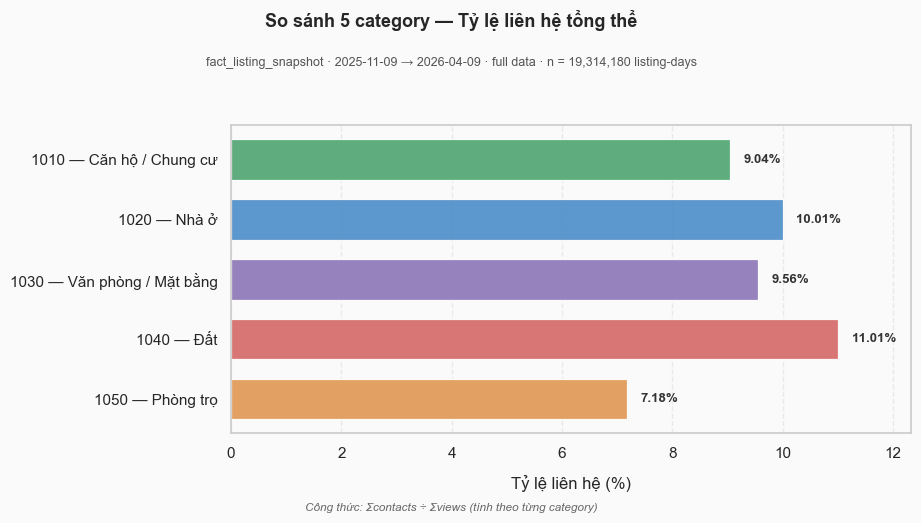

In [16]:
plot_executive_contact_rate_bars(ranking, show=True)

## Chart 1 — Thị phần liên hệ (contacts_24h)

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_listing_snapshot/_cross/fig_02a_market_share_contacts_pie.png


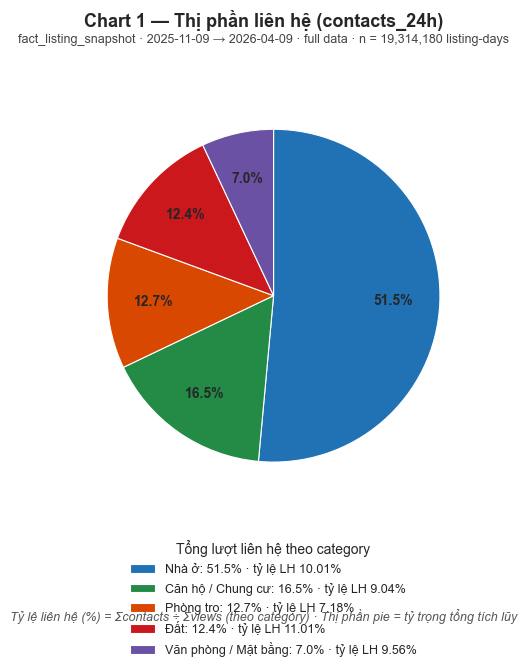

In [17]:
plot_market_share_pie(
    ranking,
    share_col="share_contacts_pct",
    title="Chart 1 — Thị phần liên hệ (contacts_24h)",
    legend_title="Tổng lượt liên hệ theo category",
    out_name="fig_02a_market_share_contacts_pie.png",
    show=True,
)

## Chart 2 — Thị phần listing-days

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_listing_snapshot/_cross/fig_02b_market_share_listing_days_pie.png


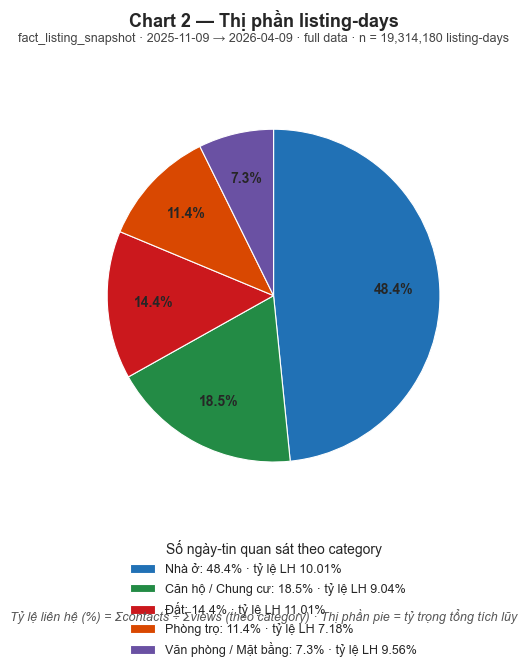

In [18]:
plot_market_share_pie(
    ranking,
    share_col="share_listing_days_pct",
    title="Chart 2 — Thị phần listing-days",
    legend_title="Số ngày-tin quan sát theo category",
    out_name="fig_02b_market_share_listing_days_pie.png",
    show=True,
)

## (Tuỳ chọn) Chạy lại step cross + 2 pie chart

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_listing_snapshot/_cross/fig_02_executive_contact_rate.png
Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_listing_snapshot/_cross/fig_02_heatmap_category_x_dow.png
Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_listing_snapshot/_cross/fig_03_heatmap_category_x_hour.png
Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_listing_snapshot/_cross/fig_04_decay_small_multiples.png
Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_listing_snapshot/_cross/fig_02a_market_share_contacts_pie.png


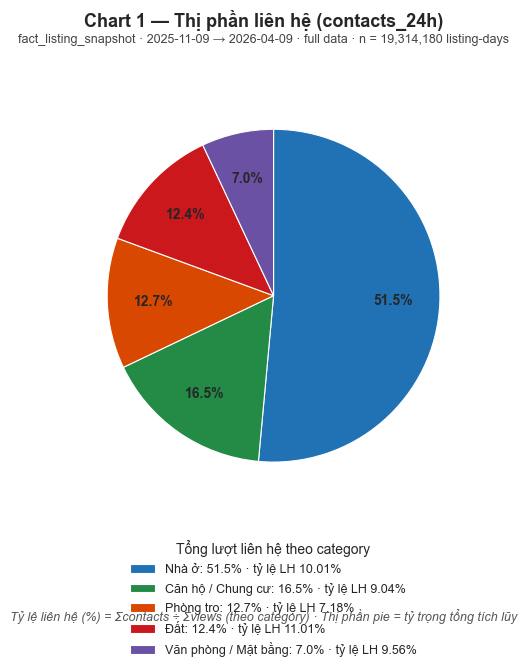

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_listing_snapshot/_cross/fig_02b_market_share_listing_days_pie.png


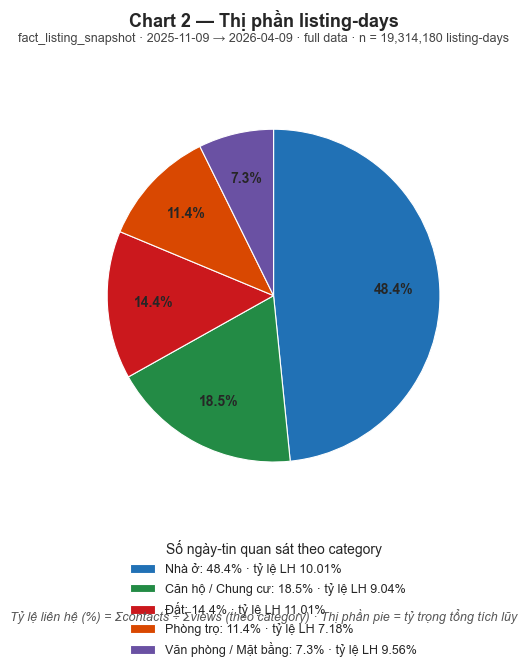

In [19]:
scorecards = [
    pd.read_csv(snap.OUT_ROOT / str(c) / "99_temporal_scorecard.csv")
    for c in snap.CATEGORIES
    if (snap.OUT_ROOT / str(c) / "99_temporal_scorecard.csv").exists()
]
snap.step_cross(con, scorecards, show=False)
ranking = load_ranking_with_shares(con)

plot_market_share_pie(
    ranking,
    share_col="share_contacts_pct",
    title="Chart 1 — Thị phần liên hệ (contacts_24h)",
    legend_title="Tổng lượt liên hệ theo category",
    out_name="fig_02a_market_share_contacts_pie.png",
    show=True,
)
plot_market_share_pie(
    ranking,
    share_col="share_listing_days_pct",
    title="Chart 2 — Thị phần listing-days",
    legend_title="Số ngày-tin quan sát theo category",
    out_name="fig_02b_market_share_listing_days_pie.png",
    show=True,
)